# Ternary Diagram

## Import Packages

In [6]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import mpltern
import seaborn as sns

## Import Data

In [7]:
data = pd.read_csv('Petrography - abundances.csv')

## Data Preparation

In [8]:
# Normalise abundances of three key components to 100%
total = data['Ol'] + data['Opx'] + data['Cpx']
data['Ol_norm']  = data['Ol']  / total * 100
data['Opx_norm'] = data['Opx'] / total * 100
data['Cpx_norm'] = data['Cpx'] / total * 100

# Classify samples based on relative abundance of three key components
def classify_sample(ol, opx, cpx):
    if ol >= 90: return 'Dunite'
    elif 40 <= ol < 90:
        if opx >= 5 and cpx >= 5: return 'Lherzolite'
        elif opx >= 5: return 'Harzburgite'
        elif cpx >= 5: return 'Wehrlite'
    elif 5 <= ol < 40:
        if opx >= 5 and cpx >= 5: return 'Olivine Websterite'
        elif opx >= 5: return 'Ol-Orthopyroxenite'
        elif cpx >= 5: return 'Ol-Clinopyroxenite'
    else: # ol < 5
        if opx >= 90: return 'Orthopyroxenite'
        if cpx >= 90: return 'Clinopyroxenite'
        return 'Websterite'
    return 'Unclassified'

# Store result of above classifications as a list
data['Class'] = [classify_sample(o, p, c) for o, p, c in zip(data['Ol_norm'], data['Opx_norm'], data['Cpx_norm'])]

## Figure Setup

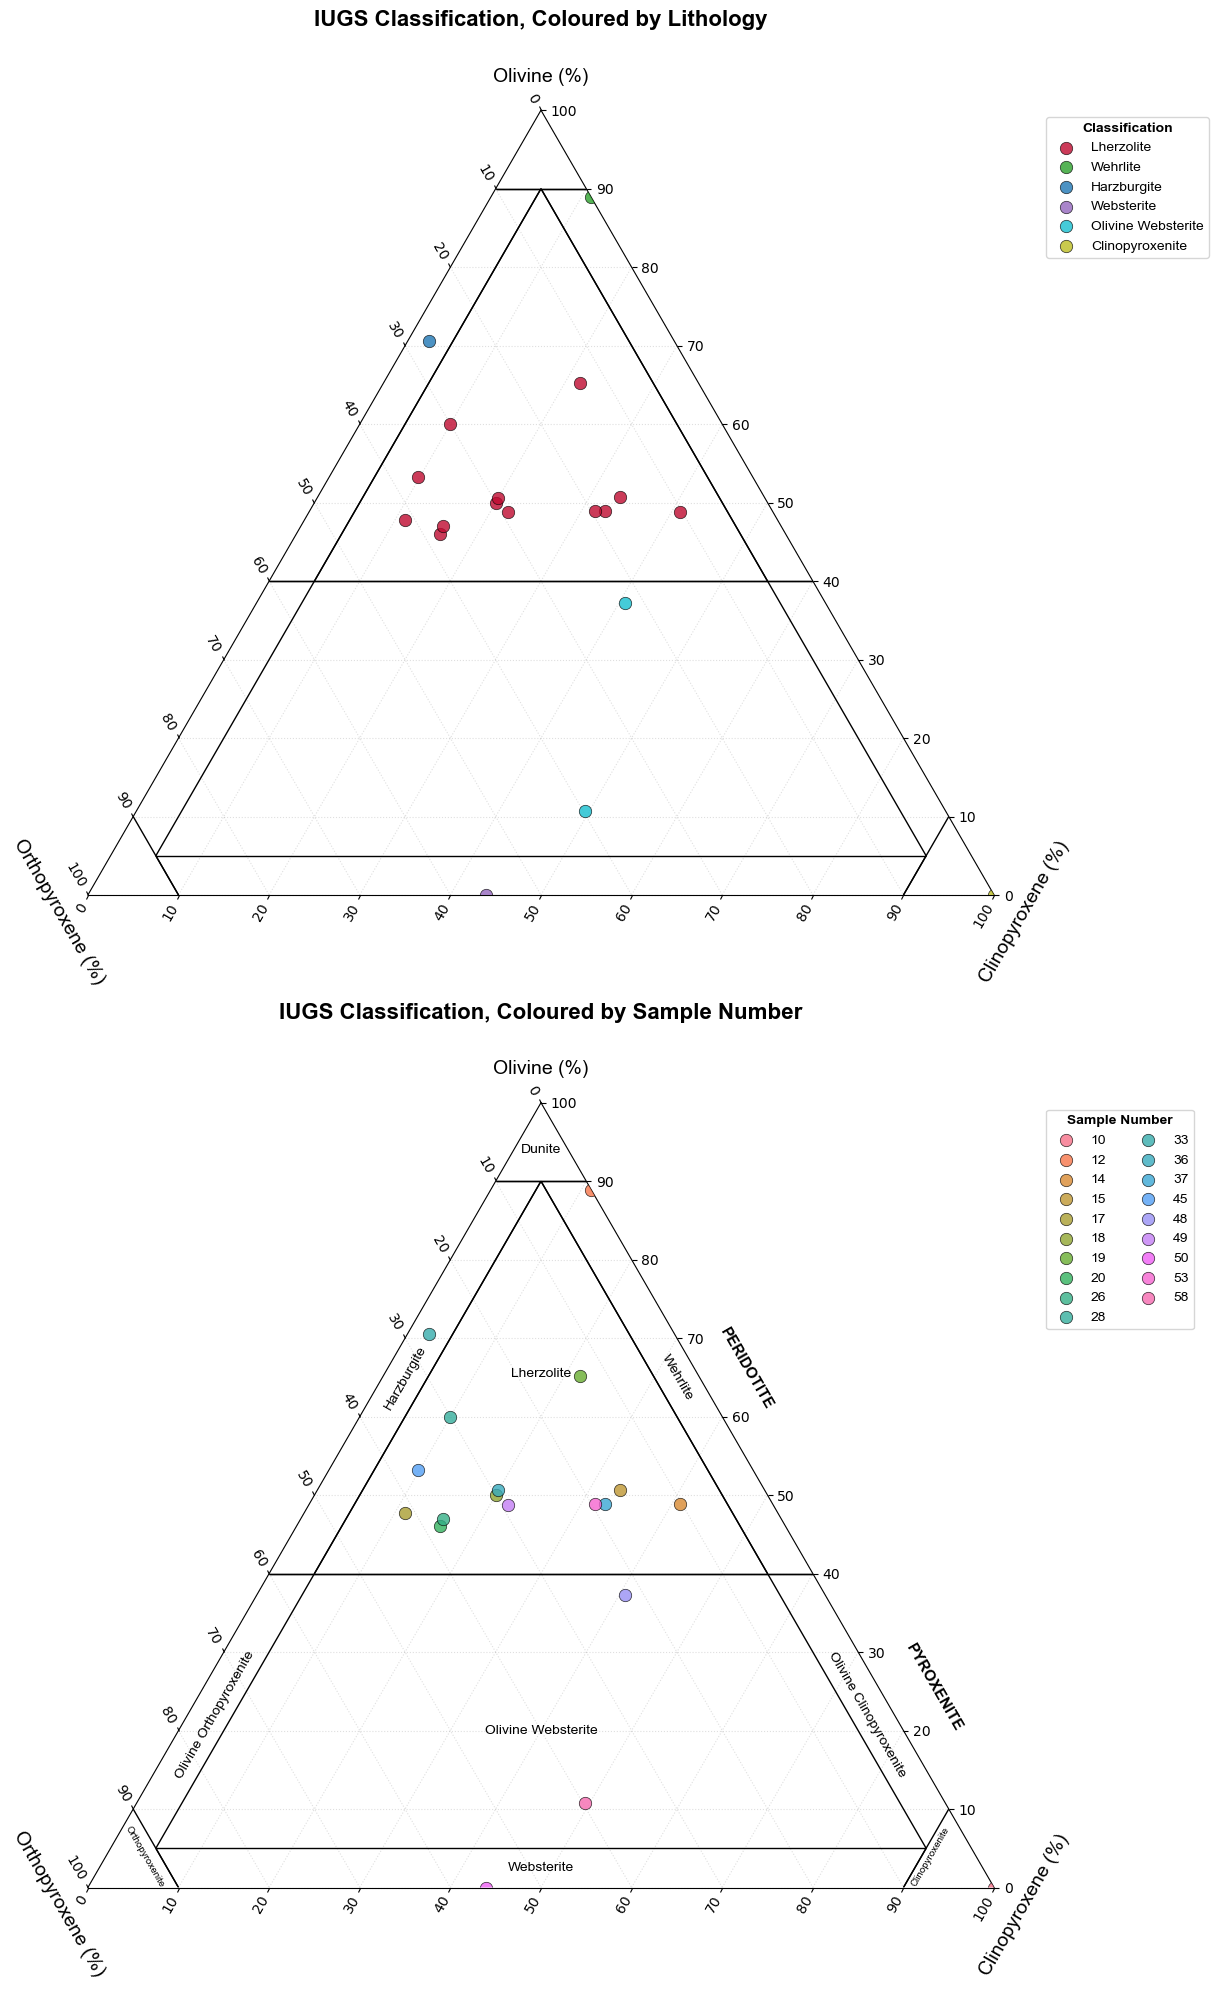

In [9]:
# Create figure with 2 rows, using mpltern for a ternary diagram
fig, (ax1, ax2) = plt.subplots(2, 1, 
    subplot_kw=dict(projection='ternary', ternary_sum=100.0), 
    figsize=(12, 20)
)

# Create loop to add classification lines of IUGS (https://www.mindat.org/photo-471844.html) to both plots
line_kwargs = dict(color='k', lw=1, solid_capstyle='butt', zorder=4) # define line style once, with 'butt' capstyle to have clean intercepts

for ax in [ax1, ax2]:
    ax.plot([90, 90], [0, 10], [10, 0], **line_kwargs)
    ax.plot([40, 40], [0, 60], [60, 0], **line_kwargs)
    ax.plot([40, 90], [5, 5], [55, 5], **line_kwargs)
    ax.plot([40, 90], [55, 5], [5, 5], **line_kwargs)
    ax.plot([0, 5], [10, 5], [90, 90], **line_kwargs) 
    ax.plot([0, 5], [90, 90], [10, 5], **line_kwargs)
    ax.plot([40, 40],[0, 60],[60, 0], **line_kwargs)
    ax.plot([5, 5],[5, 90],[90, 5], **line_kwargs)
    ax.plot([90, 90],[0, 10],[10, 0], **line_kwargs)
    ax.plot([5, 90],[5, 5],[90, 5], **line_kwargs)
    ax.plot([0,10],[90, 90],[10, 0], **line_kwargs)
    ax.plot([5, 90],[90, 5],[5, 5], **line_kwargs)
    ax.plot([0,10],[10, 0],[90, 90], **line_kwargs)

#Create consistent font type and size for whole plot
font_style = {'family': 'Arial', 'size': 10}

# Add classification labels to bottom diagram only
for ax in [ax2]:
    ax.text(94, 3, 3, "Dunite", **font_style, ha='center', va='center')
    ax.text(65, 17.5, 17.5, "Lherzolite", **font_style, ha='center')
    ax.text(20, 40, 40, "Olivine Websterite", **font_style, ha='center', va='center')
    ax.text(2.5, 48.75, 48.75, "Websterite", **font_style, ha='center', va='center')
    ax.text(65, 32.5, 2.5, "Harzburgite", **font_style, ha='center', va='center', rotation=60)
    ax.text(65, 2.5, 32.5, "Wehrlite", **font_style, ha='center', va='center', rotation=-60)
    ax.text(22, 75, 3, "Olivine Orthopyroxenite", **font_style, ha='center', va='center', rotation=60)
    ax.text(22, 3, 75, "Olivine Clinopyroxenite", **font_style, ha='center', va='center', rotation=-60)
    ax.text(0.1, 96, 3.9, "Orthopyroxenite", family='Arial', fontsize=7, rotation=-60)
    ax.text(0.15, 9.25, 90.6, "Clinopyroxenite", family='Arial', fontsize=7, rotation=60)
    ax.text(61, 0, 39, "PERIDOTITE", fontsize=11, fontweight='bold', rotation=-60, family='Arial')
    ax.text(20, 0, 80, "PYROXENITE", fontsize=11, fontweight='bold', rotation=-60, family='Arial')

# --- First plot ---

# Create colour for each classification
palette = {
    'Dunite': '#FF8C00', 
    'Lherzolite': '#BF0A30', 
    'Wehrlite': '#2CA02C',
    'Harzburgite': '#1F77B4', 
    'Websterite': '#9467BD', 
    'Olivine Websterite': '#17BECF',
    'Olivine Orthopyroxenite': '#8C564B',
    'Olivine Clinopyroxenite': '#E377C2',
    'Orthopyroxenite': '#7F7F7F',
    'Clinopyroxenite': '#BCBD22'
}

for cls, color in palette.items():
    subset = data[data['Class'] == cls]
    if not subset.empty:
        ax1.scatter(subset['Ol_norm'], subset['Opx_norm'], subset['Cpx_norm'],
                    label=cls, color=color, edgecolor='k', linewidth = 0.5, s=80, alpha=0.8, zorder=5)

# --- Second plot ---

# Create colours for each unique sample
samples = data['SampleNo.'].unique()
sample_palette = sns.color_palette("husl", len(samples))
sample_color_map = dict(zip(samples, sample_palette))

for sample in samples:
    subset = data[data['SampleNo.'] == sample]
    if not subset.empty:
        ax2.scatter(subset['Ol_norm'], subset['Opx_norm'], subset['Cpx_norm'],
                    label=sample, 
                    color=sample_color_map[sample], 
                    edgecolor='k', 
                    linewidth=0.5,
                    s=80, alpha=0.8, zorder=5)

# --- Formatting both ---

# Create loop for axes labels, ticks, and grid
for ax in [ax1, ax2]:
    ax.set_tlabel("Olivine (%)", family='Arial', fontsize=14)
    ax.set_llabel("Orthopyroxene (%)", family='Arial', fontsize=14)
    ax.set_rlabel("Clinopyroxene (%)", family='Arial', fontsize=14)
    ticks = np.arange(0, 101, 10)
    ax.taxis.set_ticks(ticks)
    ax.laxis.set_ticks(ticks)
    ax.raxis.set_ticks(ticks)
    ax.grid(True, linestyle=':', alpha=0.4)

leg1 = ax1.legend(prop=font_style, loc='upper left', bbox_to_anchor=(1.05, 1), title='Classification')
leg2 = ax2.legend(prop=font_style, loc='upper left', bbox_to_anchor=(1.05, 1), title='Sample Number', ncol=2)
for leg in [leg1, leg2]:
    plt.setp(leg.get_title(), family='Arial', fontsize=10, fontweight='bold')

ax1.set_title("IUGS Classification, Coloured by Lithology", family='Arial', fontsize=16, fontweight='bold', pad=30)
ax2.set_title("IUGS Classification, Coloured by Sample Number", family='Arial', fontsize=16, fontweight='bold', pad=30)

plt.tight_layout() 
plt.savefig('Kaapvaal_Two_Ternaries_IUGS.svg', dpi=300, bbox_inches='tight')
plt.show()

## Second Plot: Removing ax2 and resizing ax1

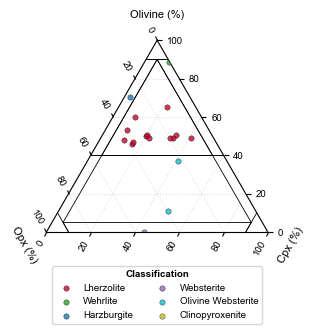

In [10]:
# Create figure using mpltern for a ternary diagram
fig, ax1 = plt.subplots(1, 1, 
    subplot_kw=dict(projection='ternary', ternary_sum=100.0), 
    figsize=(3.25, 4.5) 
)

# Add classification lines of IUGS (https://www.mindat.org/photo-471844.html)
line_kwargs = dict(color='k', lw=0.6, solid_capstyle='butt', zorder=4) # Consistent line style

ax1.plot([90, 90], [0, 10], [10, 0], **line_kwargs)
ax1.plot([40, 40], [0, 60], [60, 0], **line_kwargs)
ax1.plot([40, 90], [5, 5], [55, 5], **line_kwargs)
ax1.plot([40, 90], [55, 5], [5, 5], **line_kwargs)
ax1.plot([0, 5], [10, 5], [90, 90], **line_kwargs) 
ax1.plot([0, 5], [90, 90], [10, 5], **line_kwargs)
ax1.plot([40, 40],[0, 60],[60, 0], **line_kwargs)
ax1.plot([5, 5],[5, 90],[90, 5], **line_kwargs)
ax1.plot([90, 90],[0, 10],[10, 0], **line_kwargs)
ax1.plot([5, 90],[5, 5],[90, 5], **line_kwargs)
ax1.plot([0,10],[90, 90],[10, 0], **line_kwargs)
ax1.plot([5, 90],[90, 5],[5, 5], **line_kwargs)
ax1.plot([0,10],[10, 0],[90, 90], **line_kwargs)

# Create consistent font type and size for whole plot
font_style = {'family': 'Arial', 'size': 7}

# Assign colour to each classification
palette = {
    'Dunite': '#FF8C00', 'Lherzolite': '#BF0A30', 'Wehrlite': '#2CA02C',
    'Harzburgite': '#1F77B4', 'Websterite': '#9467BD', 'Olivine Websterite': '#17BECF',
    'Olivine Orthopyroxenite': '#8C564B', 'Olivine Clinopyroxenite': '#E377C2',
    'Orthopyroxenite': '#7F7F7F', 'Clinopyroxenite': '#BCBD22'
}

for cls, color in palette.items():
    subset = data[data['Class'] == cls]
    if not subset.empty:
        ax1.scatter(subset['Ol_norm'], subset['Opx_norm'], subset['Cpx_norm'],
                    label=cls, color=color, edgecolor='k', linewidth=0.3, 
                    s=15, alpha=0.8, zorder=5)

# Formatting
ax1.set_tlabel("Olivine (%)", family='Arial', fontsize=8)
ax1.set_llabel("Opx (%)", family='Arial', fontsize=8)
ax1.set_rlabel("Cpx (%)", family='Arial', fontsize=8)

ticks = np.arange(0, 101, 20)
ax1.taxis.set_ticks(ticks)
ax1.laxis.set_ticks(ticks)
ax1.raxis.set_ticks(ticks)

# Setup loop to control size and font of tick labels
for axis in [ax1.taxis, ax1.laxis, ax1.raxis]:
    axis.set_tick_params(labelsize=7) 
    for label in axis.get_ticklabels():
        label.set_fontfamily('Arial')
ax1.grid(True, linestyle=':', alpha=0.4)

# Place legend below plot
leg1 = ax1.legend(prop={'family': 'Arial', 'size': 7}, loc='upper center', 
                  bbox_to_anchor=(0.5, -0.15), title='Classification', ncol=2)
plt.setp(leg1.get_title(), family='Arial', fontsize=7, fontweight='bold') # Change legend font and fontsize

plt.tight_layout() 
plt.savefig('Kaapvaal_Ternary.svg', dpi=300, bbox_inches='tight')
plt.show()

# Olivine Histogram

## Import Packages

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Import Data

In [12]:
df_local = pd.read_csv('Olivine filtered.csv')
df_global = pd.read_csv('Xenolith dataset 20260313 - Olivine.csv') # Global dataset from: https://zenodo.org/records/18993479

# Clean (forcing columns to be numbers)
for df in [df_local, df_global]:
    df['MgNo'] = pd.to_numeric(df['MgNo'], errors='coerce')

# Clean (removing data where value are blank)
clean_local = df_local.dropna(subset=['MgNo'])
clean_global = df_global.dropna(subset=['MgNo'])

## First Figure Setup

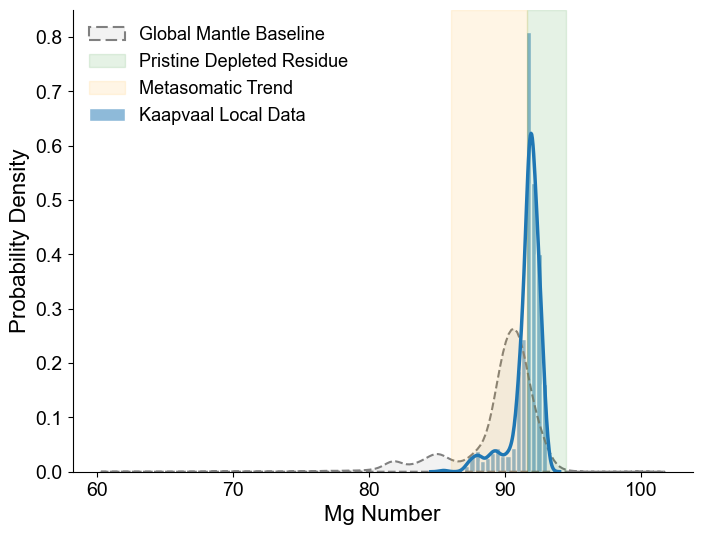

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Local Histogram and KDE
sns.histplot(clean_local['MgNo'], ax=ax, bins=20, stat='density', 
             color='#1f77b4', label='Kaapvaal Local Data', alpha=0.5, edgecolor='w')
sns.kdeplot(clean_local['MgNo'], ax=ax, color='#1f77b4', linewidth=2.5)

# Plot Global KDE
sns.kdeplot(clean_global['MgNo'], color='gray', linewidth=1.5, 
            label='Global Mantle Baseline', linestyle='--', fill=True, alpha=0.1)

# Add Interpretation Shading
ax.axvspan(91.6, 94.5, color='green', alpha=0.1, label='Pristine Depleted Residue')
ax.axvspan(86, 91.6, color='orange', alpha=0.1, label='Metasomatic Trend')

# Formatting
plt.xlabel('Mg Number', family='Arial', fontsize=16)
plt.ylabel('Probability Density', family='Arial', fontsize=16)
plt.legend(frameon=False, loc='upper left', prop={'family': 'Arial', 'size': 13})
ax.tick_params(axis='both', which='major', labelsize=14)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily('Arial')
    
sns.despine()

plt.savefig('MgNoDistribution.svg', dpi=300, bbox_inches='tight', transparent=False)

plt.show()

## Second Figure Setup (Narrower Range, with Mean)

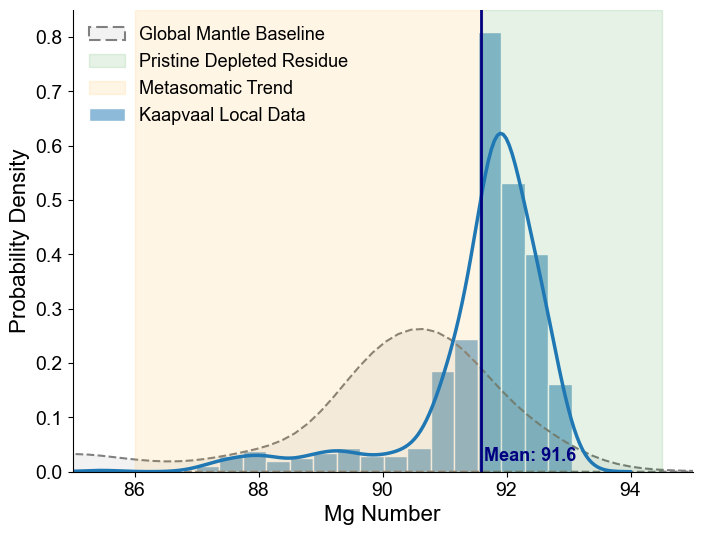

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Local Histogram and KDE
sns.histplot(clean_local['MgNo'], ax=ax, bins=20, stat='density', 
             color='#1f77b4', label='Kaapvaal Local Data', alpha=0.5, edgecolor='w')
sns.kdeplot(clean_local['MgNo'], ax=ax, color='#1f77b4', linewidth=2.5)

# Plot Global KDE
sns.kdeplot(clean_global['MgNo'], color='gray', linewidth=1.5, 
            label='Global Mantle Baseline', linestyle='--', fill=True, alpha=0.1)

# Narrow x axis range
ax.set_xlim(85, 95)

# Add Interpretation Shading
ax.axvspan(91.6, 94.5, color='green', alpha=0.1, label='Pristine Depleted Residue')
ax.axvspan(86, 91.6, color='orange', alpha=0.1, label='Metasomatic Trend')

# Add mean line
mean_val = clean_local['MgNo'].mean()
ax.axvline(mean_val, color='navy', linestyle='-', linewidth=2)

# Add mean label and adjust position
ax.text(mean_val +1.53, 0.02, f"Mean: {mean_val:.1f}", 
        color='navy', family='Arial', fontsize=13, 
        fontweight='bold', ha='right')

# Formatting
plt.xlabel('Mg Number', family='Arial', fontsize=16)
plt.ylabel('Probability Density', family='Arial', fontsize=16)
plt.legend(frameon=False, loc='upper left', prop={'family': 'Arial', 'size': 13})
ax.tick_params(axis='both', which='major', labelsize=14)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily('Arial') # Changing tick label font

sns.despine ()

plt.savefig('MgNoDistribution+Narrowed+Mean.svg', dpi=300, bbox_inches='tight', transparent=False)

plt.show()

# Olivine Scatter Plots

## Import Packages

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from scipy.optimize import curve_fit

## Import Data

In [16]:
df_local = pd.read_csv('Olivine filtered.csv')
type_col = 'Region'

# Clean (forcing columns to be numbers)
for df in [df_local]:
    df['MgNo'] = pd.to_numeric(df['MgNo'], errors='coerce')

# Clean (removing data where value are blank)
clean_local = df_local.dropna(subset=['MgNo'])

## Figure Setup

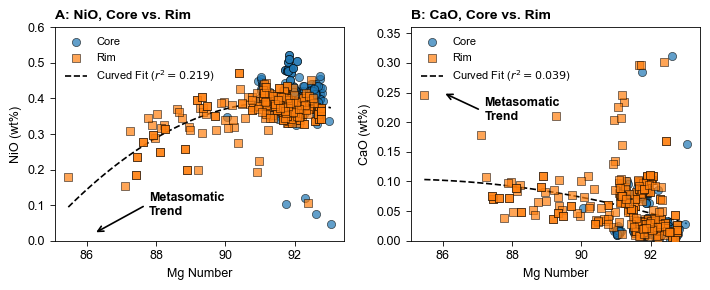

In [17]:
# Setup quadratic model for curve fitting
def curved_model(x, a, b, c):
    return a * x**2 + b * x + c

def get_r2_manual(y_true, y_pred):
    residuals = y_true - y_pred
    return 1 - (np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2))

# Setup figure with 2 scatterplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.0))

elements = ['NiO', 'CaO']
axes = [ax1, ax2]
titles = ['A: NiO, Core vs. Rim', 'B: CaO, Core vs. Rim']

# Create loop for two plots
for ax, element, title in zip(axes, elements, titles):
    x_data = clean_local['MgNo'].values
    y_data = clean_local[element].values
    
    # Fit the curve to data
    popt, _ = curve_fit(curved_model, x_data, y_data)
    
    # Create smooth line
    x_smooth = np.linspace(x_data.min(), x_data.max(), 100)
    y_smooth = curved_model(x_smooth, *popt)
    
    # Calculate R2
    r2 = get_r2_manual(y_data, curved_model(x_data, *popt))

    # Add data, with different markers for core and rim spots
    for reg, marker, color in zip(['Core', 'Rim'], ['o', 's'], ['#1f77b4', '#ff7f0e']):
        subset = clean_local[clean_local['Region'] == reg]
        ax.scatter(subset['MgNo'], subset[element], s=35, label=reg, 
                   marker=marker, edgecolors='k', linewidths=0.5, alpha=0.7, zorder=3)

    # Plot non-linear trendline
    ax.plot(x_smooth, y_smooth, color='black', linestyle='--', linewidth=1.2, 
            label=f'Curved Fit ($r^2 = {r2:.3f}$)', zorder=2)
    
    # Formatting
    ax.set_title(title, loc='left', fontweight='bold', fontsize=10, family='Arial')
    ax.set_xlabel('Mg Number', family='Arial', fontsize=9)
    ax.set_ylabel(f'{element} (wt%)', family='Arial', fontsize=9)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=9, width=0.6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily('Arial') # Changing tick label font

    # Adjust spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        
    ax.legend(frameon=False, loc='upper left', prop={'family': 'Arial', 'size': 8}) # Changing legend font and fontsize

# --- Add annotations for metasomatic trends ---
# Set position for plot A
nio_x, nio_y = 87.8, 0.1          # Alter text position to avoid overlap
nio_arr_x, nio_arr_y = 86.2, 0.02 # Alter arrow position

# Set position for plot B
cao_x, cao_y = 87.2, 0.22       # Alter text position to avoid overlap
cao_arr_x, cao_arr_y = 86, 0.25 # Alter arrow position

# Add text and arrows and format for plot A and plot B
ax1.text(nio_x, nio_y, 'Metasomatic\nTrend', fontweight='bold', ha='left', va='center', family='Arial', fontsize=9)
ax1.annotate('', xy=(nio_arr_x, nio_arr_y), xytext=(nio_x - 0.1, nio_y + 0), # Changing arrow position in relation to text
             arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax2.text(cao_x, cao_y, 'Metasomatic\nTrend', fontweight='bold', ha='left', va='center', family='Arial', fontsize=9)
ax2.annotate('', xy=(cao_arr_x, cao_arr_y), xytext=(cao_x - 0.1, cao_y + 0), # Changing arrow position in relation to text
             arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

# Change axis limits for clearer trends
ax1.set_ylim(0, 0.6) 
ax2.set_ylim(0, 0.36) 

plt.tight_layout()
plt.savefig('olivine_curved_evolution_filtered.svg', dpi=300, bbox_inches='tight')
plt.show()

## Second Figure setup: Remove plot B

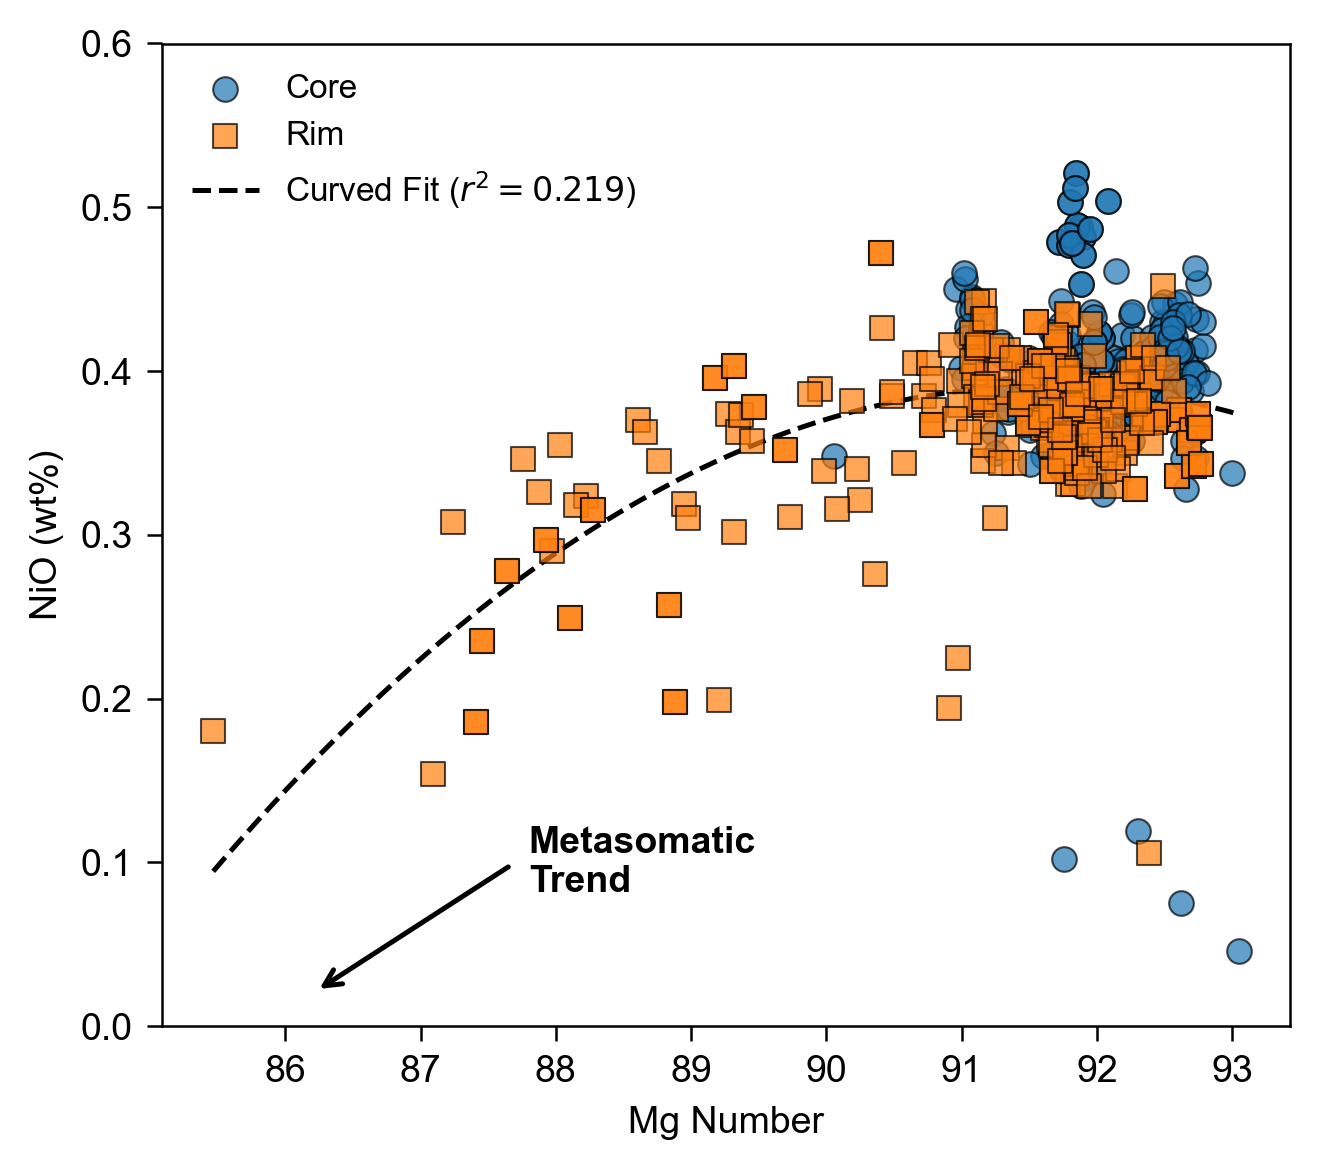

In [18]:
# Setup quadratic model for curve # Setup figure with 2 scatterplots
def curved_model(x, a, b, c):
    return a * x**2 + b * x + c

def get_r2_manual(y_true, y_pred):
    residuals = y_true - y_pred
    return 1 - (np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2))

# Setup figure with 1 scatterplot
fig, ax1 = plt.subplots(1, 1, figsize=(4.5, 4.0), dpi=300)

element = 'NiO'

# Add data
x_data = clean_local['MgNo'].values
y_data = clean_local[element].values

# Fit the curve to data, create a smooth line, and calculate r2
popt, _ = curve_fit(curved_model, x_data, y_data)
x_smooth = np.linspace(x_data.min(), x_data.max(), 100)
y_smooth = curved_model(x_smooth, *popt)
r2 = get_r2_manual(y_data, curved_model(x_data, *popt))

# Add data, with different markers for core and rim spots
for reg, marker in zip(['Core', 'Rim'], ['o', 's']):
    subset = clean_local[clean_local['Region'] == reg]
    ax1.scatter(subset['MgNo'], subset[element], s=35, label=reg, 
                marker=marker, edgecolors='k', linewidths=0.5, alpha=0.7, zorder=3)

# Plot non-linear trendline
ax1.plot(x_smooth, y_smooth, color='black', linestyle='--', linewidth=1.2, 
        label=f'Curved Fit ($r^2 = {r2:.3f}$)', zorder=2)

# Formatting
ax1.set_xlabel('Mg Number', family='Arial', fontsize=9)
ax1.set_ylabel(f'{element} (wt%)', family='Arial', fontsize=9)

# Tick formatting and spine thickness
for spine in ax1.spines.values():
    spine.set_linewidth(0.6) 
ax1.tick_params(axis='both', which='major', labelsize=9, width=0.6)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontfamily('Arial') # Setting tick label font
    
ax1.legend(frameon=False, loc='upper left', prop={'family': 'Arial', 'size': 8})

# Add text and arrow for metasomatic trend
nio_x, nio_y = 87.8, 0.1          # Alter text position here to avoid overlap
nio_arr_x, nio_arr_y = 86.2, 0.02 # Alter arrow position here

ax1.text(nio_x, nio_y, 'Metasomatic\nTrend', fontweight='bold', 
         ha='left', va='center', family='Arial', fontsize=9)
ax1.annotate('', xy=(nio_arr_x, nio_arr_y), xytext=(nio_x - 0.1, nio_y + 0),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

# Change axis limits for clearer trends
ax1.set_ylim(0, 0.6) 

plt.tight_layout()
plt.savefig('olivine_nio.svg', dpi=300, bbox_inches='tight')
plt.show()

# Garnet Classification

## Import Packages

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import Data

In [20]:
data = pd.read_csv('Garnet filtered.csv')
Cr = data['Cr2O3']
Ca = data['CaO']

sample_col = "SampleNo."
samples = pd.unique(data['SampleNo.'])
colors = sns.color_palette("husl", len(samples))

## Figure Setup

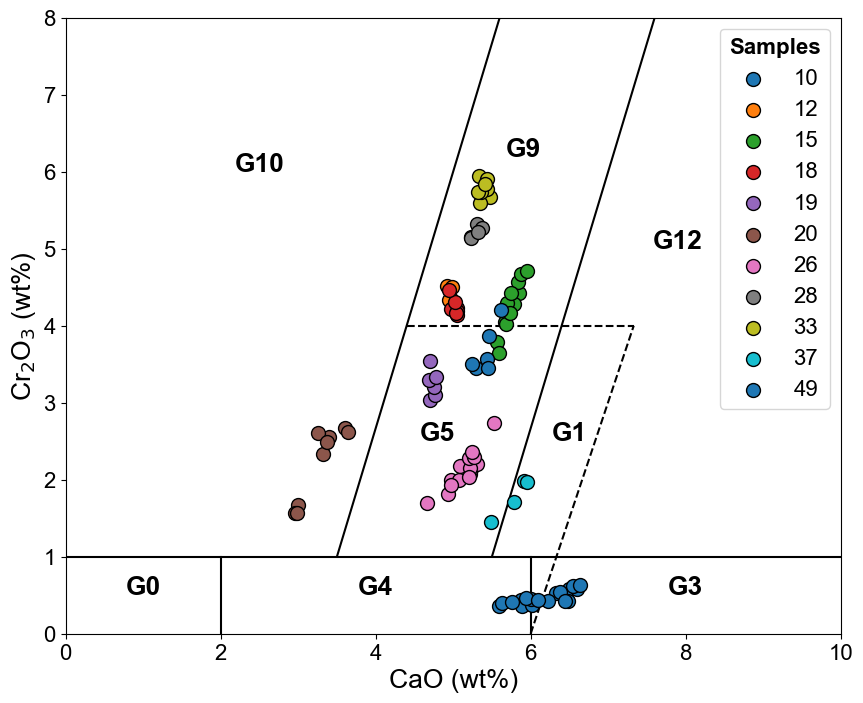

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

# Add boundary classification lines from Grütter et al., 2004. DOI: https://doi.org/10.1016/j.lithos.2004.04.012
ax.axhline(y=1, color='black', linewidth=1.5, zorder=1)
ax.plot([2, 2], [0, 1], color='black', linewidth=1.5)
ax.plot([6, 6], [0, 1], color='black', linewidth=1.5)
ax.plot([3.5, 5.6], [1, 8], color='black', linewidth=1.5)
ax.plot([5.5, 7.6], [1, 8], color='black', linewidth=1.5)
ax.plot([6.0, 7.33], [0, 4], color='black', linewidth=1.5, linestyle='--', zorder=2)
ax.plot([4.4, 7.33], [4, 4], color='black', linewidth=1.5, linestyle='--', zorder=2)

# Add classification labels
label_params = {'fontsize': 19, 'fontweight': 'bold', 'ha': 'center', 'family': 'Arial'}
ax.text(1.0, 0.5, 'G0', **label_params)
ax.text(4.0, 0.5, 'G4', **label_params)
ax.text(8.0, 0.5, 'G3', **label_params)
ax.text(4.8, 2.5, 'G5', **label_params)
ax.text(6.5, 2.5, 'G1', **label_params)
ax.text(2.5, 6.0, 'G10', **label_params)
ax.text(5.9, 6.2, 'G9', **label_params)
ax.text(7.9, 5.0, 'G12', **label_params)

# Plot data
for sample in data['SampleNo.'].unique():
    subset = data[data['SampleNo.'] == sample]
    ax.scatter(subset['CaO'], subset['Cr2O3'], label=sample, s=100, edgecolors='k', zorder=5)

# Format plot
ax.set_xlabel('CaO (wt%)', fontsize=19, family='Arial')
ax.set_ylabel(r'Cr$_2$O$_3$ (wt%)', fontsize=19, family='Arial')
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.grid(False)

# Change font of tick labels
ax.tick_params(axis='both', which='major', labelsize=16)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily('Arial')

# Change font of legend
leg = ax.legend(title="Samples", loc='upper right', prop={'family': 'Arial', 'size': 16})
plt.setp(leg.get_title(), family='Arial', fontsize=16, fontweight='bold')

plt.savefig('Grtclassfinal.svg', dpi=300, bbox_inches='tight', transparent=False)
plt.show()